## Exploring tickets Dataset

In [1]:
# import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# loading the datasets
tickets = pd.read_csv('data/raw/ticket_sales.csv')
weather = pd.read_csv('data/raw/weather_data.csv')
competitors = pd.read_csv('data/raw/competitor_prices.csv')
social = pd.read_csv('data/raw/social_media_buzz.csv')

In [4]:
# Basic info about the tickets dataset
print(f"\n Dataset has {tickets.shape[0]} rows and {tickets.shape[1]} columns.")
print("\n Columns and their data types:")
print(tickets.dtypes)



 Dataset has 30000 rows and 12 columns.

 Columns and their data types:
ticket_id            object
event_id             object
event_name           object
event_type           object
event_date           object
sale_date            object
days_until_event      int64
seat_section         object
ticket_price        float64
quantity_sold         int64
city                 object
venue_capacity        int64
dtype: object


In [5]:
# first few rows of the tickets dataset
tickets.head()

,ticket_id,event_id,event_name,event_type,event_date,sale_date,days_until_event,seat_section,ticket_price,quantity_sold,city,venue_capacity
0,TKT_000001,EVT_0000,Taylor Swift - Chicago,Concert,2024-05-05,2024-02-10,85,VIP,330.04,2,Chicago,5000
1,TKT_000002,EVT_0000,Taylor Swift - Chicago,Concert,2024-05-05,2024-03-06,60,Floor,235.89,1,Chicago,5000
2,TKT_000003,EVT_0000,Taylor Swift - Chicago,Concert,2024-05-05,2024-04-07,28,Upper Bowl,118.07,3,Chicago,5000
3,TKT_000004,EVT_0000,Taylor Swift - Chicago,Concert,2024-05-05,2024-03-17,49,Lower Bowl,194.82,3,Chicago,5000
4,TKT_000005,EVT_0000,Taylor Swift - Chicago,Concert,2024-05-05,2024-04-02,33,VIP,422.28,3,Chicago,5000


In [10]:
# statistical summary of tickets data  
tickets.describe()

,days_until_event,ticket_price,quantity_sold,venue_capacity
count,30000.000000,30000.000000,30000.000000,30000.000000
mean,45.589233,167.271334,2.128800,6726.666667
std,25.950908,107.660962,1.240589,4864.779312
min,1.000000,35.150000,1.000000,1500.000000
25%,23.000000,82.530000,1.000000,2000.000000
50%,46.000000,135.765000,2.000000,5000.000000
75%,68.000000,225.737500,3.000000,8000.000000
max,90.000000,685.390000,6.000000,15000.000000


In [13]:
# missing values in tickets dataset
missing = tickets.isnull().sum()
missing


ticket_id           0
event_id            0
event_name          0
event_type          0
event_date          0
sale_date           0
days_until_event    0
seat_section        0
ticket_price        0
quantity_sold       0
city                0
venue_capacity      0
dtype: int64

In [17]:
# price statistics
print(f"Average Ticket Price: ${tickets['ticket_price'].mean():.2f}")

print(f"Median Ticket Price: ${tickets['ticket_price'].median():.2f}")

print(f"Max Ticket Price: ${tickets['ticket_price'].max():.2f}")

print(f"Price range: ${tickets['ticket_price'].min()} - ${tickets['ticket_price'].max()}")

Average Ticket Price: $167.27
Median Ticket Price: $135.76
Max Ticket Price: $685.39
Price range: $35.15 - $685.39


In [25]:
# Ticket volume 
print(f"Total tickets sold: {tickets['quantity_sold'].sum()}")

print(f"Total revenue : ${(tickets['ticket_price']* tickets['quantity_sold']).sum():.2f}")

Total tickets sold: 63864
Total revenue : $10695574.27


In [21]:
tickets['event_type'].value_counts()

event_type
Sports      7800
Festival    6200
Concert     5600
Comedy      5600
Theater     4800
Name: count, dtype: int64

In [22]:
# seat sections
tickets['seat_section'].value_counts()

seat_section
Upper Bowl           6103
VIP                  6017
General Admission    6011
Floor                5946
Lower Bowl           5923
Name: count, dtype: int64

In [23]:
# cities 
tickets['city'].value_counts()

city
New York       7200
Miami          6400
Los Angeles    5600
Chicago        5400
Seattle        5400
Name: count, dtype: int64

## Exploring weather dataset

In [26]:
print(f"Dataset has {weather.shape[0]} rows and {weather.shape[1]} columns.")

Dataset has 1830 rows and 5 columns.


In [27]:
weather.head()

,date,city,temperature,rain,humidity
0,2024-01-01,New York,38.8,0,57.6
1,2024-01-01,Los Angeles,48.1,0,62.9
2,2024-01-01,Chicago,40.8,0,71.5
3,2024-01-01,Miami,56.2,1,64.5
4,2024-01-01,Seattle,35.5,1,48.8


In [28]:
weather.dtypes

date            object
city            object
temperature    float64
rain             int64
humidity       float64
dtype: object

In [29]:
weather.describe()

,temperature,rain,humidity
count,1830.000000,1830.000000,1830.000000
mean,61.336393,0.334973,60.036721
std,16.793807,0.472110,11.773723
min,25.100000,0.000000,40.000000
25%,48.600000,0.000000,49.900000
50%,60.500000,0.000000,59.650000
75%,73.375000,1.000000,70.400000
max,102.700000,1.000000,80.000000


## Exploring competitors dataset

In [30]:
print(f"Dataset has {competitors.shape[0]} rows and {competitors.shape[1]} columns.")

Dataset has 750 rows and 6 columns.


In [31]:
competitors.head()

,event_id,event_name,seat_section,competitor_price,competitor_name,date_checked
0,EVT_0000,Taylor Swift - Chicago,VIP,362.41,Ticketmaster,2024-04-23
1,EVT_0000,Taylor Swift - Chicago,Floor,285.97,SeatGeek,2024-04-27
2,EVT_0000,Taylor Swift - Chicago,Lower Bowl,176.92,Vivid Seats,2024-04-19
3,EVT_0000,Taylor Swift - Chicago,Upper Bowl,103.97,StubHub,2024-04-15
4,EVT_0000,Taylor Swift - Chicago,General Admission,105.08,SeatGeek,2024-04-13


In [33]:
competitors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   event_id          750 non-null    object 
 1   event_name        750 non-null    object 
 2   seat_section      750 non-null    object 
 3   competitor_price  750 non-null    float64
 4   competitor_name   750 non-null    object 
 5   date_checked      750 non-null    object 
dtypes: float64(1), object(5)
memory usage: 35.3+ KB


In [34]:
competitors.describe()

,competitor_price
count,750.000000
mean,168.176080
std,106.096825
min,38.060000
25%,85.632500
50%,131.340000
75%,231.977500
max,545.160000


In [35]:
# competitors
competitors['competitor_name'].value_counts()

competitor_name
Ticketmaster    199
SeatGeek        199
Vivid Seats     181
StubHub         171
Name: count, dtype: int64

## Exploring social media buzz dataset

In [36]:
print(f"Dataset has {social.shape[0]} rows and {social.shape[1]} columns.")

Dataset has 4500 rows and 6 columns.


In [37]:
social.head()

,event_id,event_name,date,mentions,sentiment_score,trending
0,EVT_0000,Taylor Swift - Chicago,2024-04-05,3442,0.64,1
1,EVT_0000,Taylor Swift - Chicago,2024-04-06,3377,0.84,1
2,EVT_0000,Taylor Swift - Chicago,2024-04-07,3674,0.91,1
3,EVT_0000,Taylor Swift - Chicago,2024-04-08,3968,0.84,1
4,EVT_0000,Taylor Swift - Chicago,2024-04-09,2926,0.69,0


In [38]:
social.dtypes

event_id            object
event_name          object
date                object
mentions             int64
sentiment_score    float64
trending             int64
dtype: object

In [39]:
social.describe()

,mentions,sentiment_score,trending
count,4500.000000,4500.000000,4500.000000
mean,2336.318889,0.773104,0.200667
std,1280.035291,0.101559,0.400544
min,814.000000,0.600000,0.000000
25%,1476.750000,0.680000,0.000000
50%,1970.000000,0.770000,0.000000
75%,2650.250000,0.860000,0.000000
max,8580.000000,0.950000,1.000000


## Visualizations

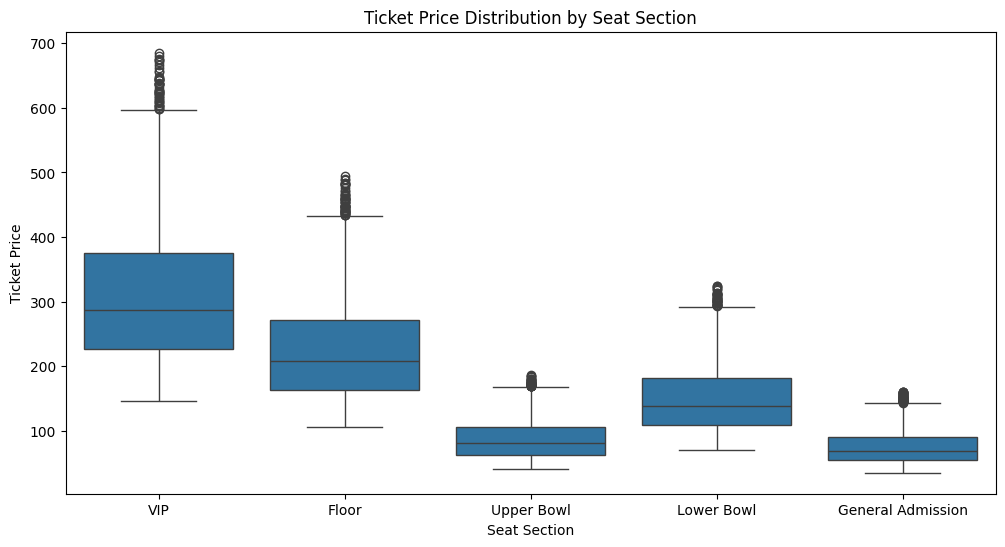

In [40]:
# price distribution by seat section
plt.figure(figsize=(12, 6))
sns.boxplot(x='seat_section', y='ticket_price', data=tickets)
plt.title('Ticket Price Distribution by Seat Section')
plt.xlabel('Seat Section')
plt.ylabel('Ticket Price')
plt.show()

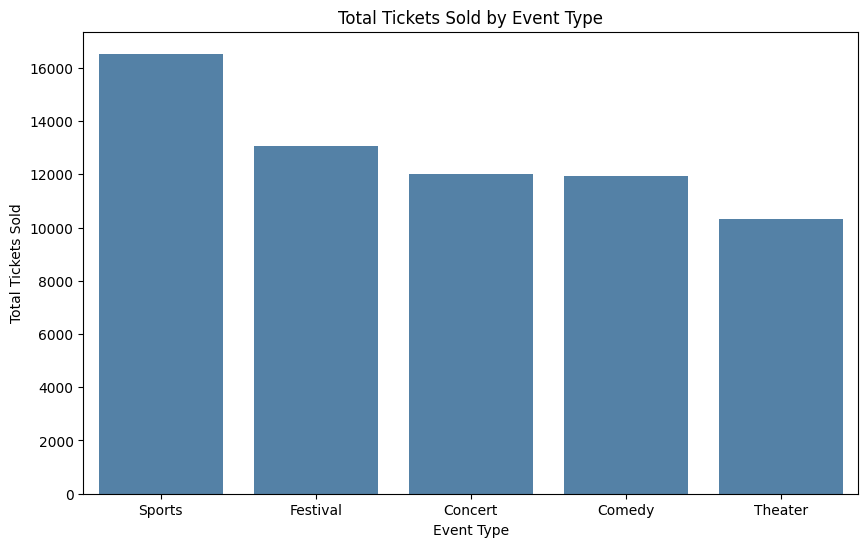

In [42]:
# sales by event type
event_sales = tickets.groupby('event_type')['quantity_sold'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=event_sales.index, y=event_sales.values ,color='steelblue')
plt.title('Total Tickets Sold by Event Type')
plt.xlabel('Event Type')
plt.ylabel('Total Tickets Sold')
plt.show()

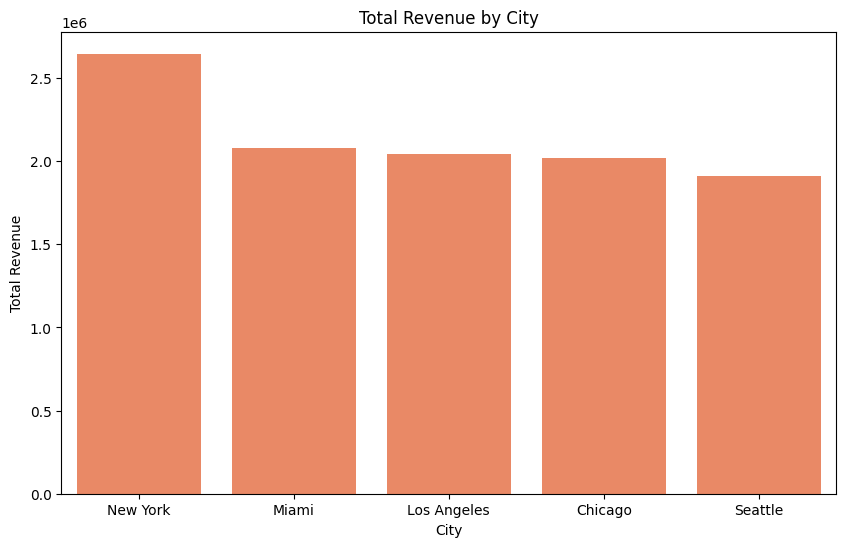

In [ ]:
# revenue by city
tickets['revenue'] = tickets['ticket_price'] * tickets['quantity_sold']
city_revenue = tickets.groupby('city')['revenue'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=city_revenue.index, y=city_revenue.values, color='coral')
plt.title('Total Revenue by City')
plt.xlabel('City')
plt.ylabel('Total Revenue')
plt.show()


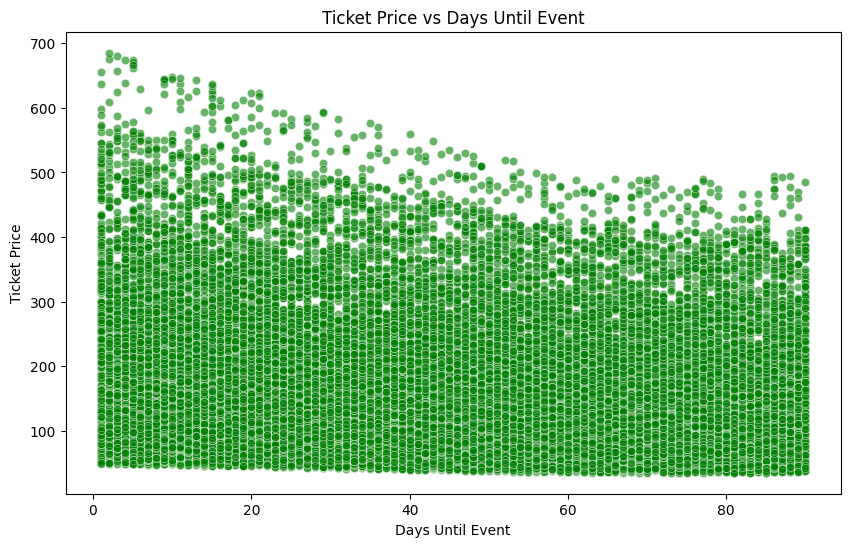

In [46]:
# price vs days until event
plt.figure(figsize=(10, 6))
sns.scatterplot(x='days_until_event', y='ticket_price', data=tickets, alpha=0.6 , color='green')
plt.title('Ticket Price vs Days Until Event')
plt.xlabel('Days Until Event')
plt.ylabel('Ticket Price')
plt.show()

<h4> Data Quality Issues checking

In [47]:
# negative prices 
negative_prices = tickets[tickets['ticket_price'] < 0]
print(f"Number of records with negative ticket prices: {negative_prices.shape[0]}")

Number of records with negative ticket prices: 0


In [48]:
# future sale dates
tickets['sale_date'] = pd.to_datetime(tickets['sale_date'])
tickets['event_date'] = pd.to_datetime(tickets['event_date'])
future_sales = tickets[tickets['sale_date'] > tickets['event_date']]
print(f"Number of records with sale date after event date: {future_sales.shape[0]}")

Number of records with sale date after event date: 0


In [49]:
# duplicates 
duplicates = tickets.duplicated().sum()
print(f"Number of duplicate records: {duplicates}")

Number of duplicate records: 0


In [50]:
# outliers in ticket prices
Q1 = tickets['ticket_price'].quantile(0.25)
Q3 = tickets['ticket_price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = tickets[(tickets['ticket_price'] < lower_bound) | (tickets['ticket_price'] > upper_bound)]
print(f"Number of outlier records in ticket prices: {outliers.shape[0]}")

Number of outlier records in ticket prices: 742


<h4> key insights :- </h4>

In [51]:
# top 5 most expensive events
top_events = tickets.groupby('event_name')['ticket_price'].max().sort_values(ascending=False).head(5)
print("Top 5 most expensive events:")
print(top_events)

Top 5 most expensive events:
event_name
Coachella - Seattle            685.39
Coachella - New York           681.00
Outside Lands - Los Angeles    676.31
Outside Lands - Chicago        674.68
Coachella - Miami              674.03
Name: ticket_price, dtype: float64


In [56]:
# best selling seat sections
best_seat_sections = tickets.groupby('seat_section')['quantity_sold'].sum().sort_values(ascending=False).head(5)
print("Top 5 best selling seat sections:")
best_seat_sections

Top 5 best selling seat sections:


seat_section
Upper Bowl           13020
VIP                  12972
General Admission    12761
Floor                12556
Lower Bowl           12555
Name: quantity_sold, dtype: int64

In [57]:
# peak sales days
tickets['sale_day_of_week'] = tickets['sale_date'].dt.day_name()
peak_sales_days = tickets.groupby('sale_day_of_week')['quantity_sold'].sum().sort_values(ascending=False).head(5)   
print("Top 5 peak sales days:")
peak_sales_days


Top 5 peak sales days:


sale_day_of_week
Monday       9448
Saturday     9202
Wednesday    9080
Tuesday      9067
Thursday     9059
Name: quantity_sold, dtype: int64

## SUMMARY REPORT

     1. TICKET SALES DATA 
        - Total Records : 30,000
        - Total Revenue : $ 10695574.27
        - Average Price : $ 167.27
        - Price Range   : $35.15 - $685.39


     2. WEATHER DATA   
        - Total Records       : 1830
        - Cities Covered      : 5
        - Average Temperature : 61.34°F


     3. COMPETITOR DATA
        - Total Records            : 750
        - Average Competitor Price : $168.18 


     4. SOCIAL MEDIA DATA 
        - Total Records      : 4500
        - Average Mentions   : 2336
        - Average Sentiments : 0.77